# Visual Product Search Engine — Preprocessing

This notebook handles all preprocessing for the **DeepFashion In-Shop Clothes Retrieval** dataset.

### What we do here:
1. Set up paths (dataset is already extracted on Kaggle)
2. Parse `list_eval_partition.txt` to get train / query / gallery splits
3. Parse `list_bbox_inshop.txt` to get bounding boxes per image
4. Merge into one master dataframe
5. Verify image paths exist on disk
6. Visualize sample images with bounding boxes
7. Verify contrastive training pairs exist
8. Save CSV files for all future notebooks

### Important Note:
This notebook does NOT crop images. Cropping is done by YOLO in the next notebook.
The bounding box coordinates from `list_bbox_inshop.txt` are saved in the CSVs
and will be used as fallback only if YOLO fails to detect anything.

### Output of this notebook:
- `master_df.csv` — all 52712 images with split + bbox info
- `train.csv` — 25882 training images
- `query.csv` — 14218 query images
- `gallery.csv` — 12612 gallery images

### Next notebook:
YOLO — runs detection on every image and produces the actual crops used by BLIP-2 and CLIP.

## Step 1: Import Libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Define Paths

The dataset is already extracted on Kaggle so we point directly to the files.
No unzipping needed.

Folder structure on Kaggle:
```
/kaggle/input/.../dataset/
    img/
        MEN/
        WOMEN/
    list_bbox_inshop.txt
    list_description_inshop.json
    list_eval_partition.txt
```

In [2]:
# Dataset Input Paths (read-only on Kaggle)
BASE_DIR  = '/kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset'
IMAGE_DIR = os.path.join(BASE_DIR, 'img')
BBOX_PATH = os.path.join(BASE_DIR, 'list_bbox_inshop.txt')
EVAL_PATH = os.path.join(BASE_DIR, 'list_eval_partition.txt')
DESC_PATH = os.path.join(BASE_DIR, 'list_description_inshop.json')

# Output Paths (writable on Kaggle)
OUTPUT_DIR = '/kaggle/working'

# Quick existence check
for name, path in [('IMAGE_DIR', IMAGE_DIR), ('BBOX_PATH', BBOX_PATH),
                   ('EVAL_PATH', EVAL_PATH), ('DESC_PATH', DESC_PATH)]:
    status = 'Found' if os.path.exists(path) else 'NOT FOUND'
    print(f'{status}  {name}: {path}')

Found  IMAGE_DIR: /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img
Found  BBOX_PATH: /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/list_bbox_inshop.txt
Found  EVAL_PATH: /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/list_eval_partition.txt
Found  DESC_PATH: /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/list_description_inshop.json


## Step 3: Parse `list_eval_partition.txt`

This file tells us which images belong to which split:
- **train** — used to fine-tune CLIP
- **query** — the search inputs during evaluation
- **gallery** — the database we search through

Format of each line:
```
img/MEN/Denim/id_00000080/02_1_front.jpg   id_00000080   train
```

In [3]:
with open(EVAL_PATH, 'r') as f:
    lines = f.readlines()

num_images = int(lines[0].strip())
header     = lines[1].strip()
print(f'Total images declared : {num_images}')
print(f'Header row            : {header}')
print(f'Sample line           : {lines[2].strip()}')

# Parse all rows
eval_records = []
for line in lines[2:]:
    parts = line.strip().split()
    if len(parts) == 3:
        image_name, item_id, split = parts
        eval_records.append({
            'image_name': image_name,
            'item_id'   : item_id,
            'split'     : split
        })

df_eval = pd.DataFrame(eval_records)

print(f'\nRows parsed: {len(df_eval)}')
print('\nSplit distribution:')
print(df_eval['split'].value_counts().to_string())
print(f'\nUnique item IDs: {df_eval["item_id"].nunique()}')
df_eval.head()

Total images declared : 52712
Header row            : image_name item_id evaluation_status
Sample line           : img/WOMEN/Dresses/id_00000002/02_1_front.jpg                           id_00000002 train

Rows parsed: 52712

Split distribution:
split
train      25882
query      14218
gallery    12612

Unique item IDs: 7982


,image_name,item_id,split
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train


## Step 4: Parse `list_bbox_inshop.txt`

This file gives us the bounding box of the clothing item in each image.
These coordinates will be saved in our CSV files and used as fallback
if YOLO fails to detect anything in the next notebook.

Format of each line:
```
image_name   clothes_type   pose_type   x1   y1   x2   y2
```

- **clothes_type**: 1 = upper-body, 2 = lower-body, 3 = full-body
- **pose_type**: 1 = front, 2 = side, 3 = back, 4 = zoom-out, 5 = zoom-in, 6 = standalone
- **x1, y1** = top-left corner of bounding box
- **x2, y2** = bottom-right corner of bounding box

In [4]:
with open(BBOX_PATH, 'r') as f:
    lines = f.readlines()

print(f'Total bbox entries : {lines[0].strip()}')
print(f'Header             : {lines[1].strip()}')
print(f'Sample line        : {lines[2].strip()}')

bbox_records = []
for line in lines[2:]:
    parts = line.strip().split()
    if len(parts) == 7:
        bbox_records.append({
            'image_name'  : parts[0],
            'clothes_type': int(parts[1]),
            'pose_type'   : int(parts[2]),
            'x1': int(parts[3]),
            'y1': int(parts[4]),
            'x2': int(parts[5]),
            'y2': int(parts[6])
        })

df_bbox = pd.DataFrame(bbox_records)

print(f'\nRows parsed: {len(df_bbox)}')
print('\nClothes type distribution (1=upper, 2=lower, 3=full):')
print(df_bbox['clothes_type'].value_counts().to_string())
print('\nPose type distribution (1=front, 2=side, 3=back, 4=zoom-out, 5=zoom-in, 6=standalone):')
print(df_bbox['pose_type'].value_counts().to_string())
df_bbox.head()

Total bbox entries : 52712
Header             : image_name clothes_type pose_type x_1 y_1 x_2 y_2
Sample line        : img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg                    1 1 050 049 208 235

Rows parsed: 52712

Clothes type distribution (1=upper, 2=lower, 3=full):
clothes_type
1    33487
2    10494
3     8731

Pose type distribution (1=front, 2=side, 3=back, 4=zoom-out, 5=zoom-in, 6=standalone):
pose_type
1    12861
2    10923
5    10914
3    10661
4     6670
6      683


,image_name,clothes_type,pose_type,x1,y1,x2,y2
0,img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...,1,1,50,49,208,235
1,img/WOMEN/Blouses_Shirts/id_00000001/02_2_side...,1,2,119,48,136,234
2,img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...,1,3,50,42,213,240
3,img/WOMEN/Blouses_Shirts/id_00000001/02_4_full...,1,4,82,30,162,129
4,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,3,1,65,45,233,252


## Step 5: Merge into Master Dataframe

We join the eval partition info (split + item_id) with bbox info on `image_name`.
This gives us one single table with everything we need about each image.

Each row will have:
- image_name, item_id, split
- clothes_type, pose_type
- x1, y1, x2, y2 (annotation bbox — used as fallback in YOLO notebook)

In [5]:
df_master = df_eval.merge(df_bbox, on='image_name', how='left')

print(f'Master dataframe shape : {df_master.shape}')
print(f'Missing bbox entries   : {df_master["x1"].isna().sum()}')

# Drop rows with missing bboxes if any
before = len(df_master)
df_master.dropna(subset=['x1', 'y1', 'x2', 'y2'], inplace=True)
df_master.reset_index(drop=True, inplace=True)
print(f'Dropped {before - len(df_master)} rows with missing bboxes')
print(f'Final master df        : {len(df_master)} rows')

# Cast bbox columns to int
for col in ['x1', 'y1', 'x2', 'y2']:
    df_master[col] = df_master[col].astype(int)

df_master.head(10)

Master dataframe shape : (52712, 9)
Missing bbox entries   : 0
Dropped 0 rows with missing bboxes
Final master df        : 52712 rows


,image_name,item_id,split,clothes_type,pose_type,x1,y1,x2,y2
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train,3,1,65,45,233,252
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train,3,2,112,41,168,247
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train,3,4,89,34,169,167
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train,3,5,73,40,194,251
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train,2,1,51,122,160,210
5,img/WOMEN/Skirts/id_00000003/02_2_side.jpg,id_00000003,train,2,2,121,13,131,112
6,img/WOMEN/Skirts/id_00000003/02_3_back.jpg,id_00000003,train,2,3,41,30,227,180
7,img/WOMEN/Skirts/id_00000003/02_4_full.jpg,id_00000003,train,2,4,116,87,201,151
8,img/WOMEN/Skirts/id_00000003/02_7_additional.jpg,id_00000003,train,2,5,49,15,177,105
9,img/WOMEN/Blouses_Shirts/id_00000004/03_1_fron...,id_00000004,train,1,1,79,29,211,168


## Step 6: Verify Image Paths Exist on Disk

The `image_name` column looks like: `img/MEN/Denim/id_00000080/02_1_front.jpg`

Since our `IMAGE_DIR` already points to the `img/` folder,
we strip the `img/` prefix to get the correct full path.

In [6]:
def get_full_path(image_name):
    """
    Converts annotation image_name to full disk path.
    image_name example: 'img/MEN/Denim/id_00000080/02_1_front.jpg'
    IMAGE_DIR points to the 'img/' folder, so we strip the 'img/' prefix.
    """
    relative = image_name[4:] if image_name.startswith('img/') else image_name
    return os.path.join(IMAGE_DIR, relative)

# Test on first 5 images
print('Testing path resolution on first 5 images:')
for name in df_master['image_name'].head(5):
    path   = get_full_path(name)
    exists = os.path.exists(path)
    print(f'  {"Found" if exists else "NOT FOUND"}  {path}')

# Spot check 100 random images
sample_100 = df_master['image_name'].sample(100, random_state=42)
missing    = [n for n in sample_100 if not os.path.exists(get_full_path(n))]
print(f'\nSpot check 100 random images — missing: {len(missing)}')
if missing:
    print('Example missing:', missing[:3])

Testing path resolution on first 5 images:
  Found  /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
  Found  /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_2_side.jpg
  Found  /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_4_full.jpg
  Found  /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_7_additional.jpg
  Found  /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img/WOMEN/Skirts/id_00000003/02_1_front.jpg

Spot check 100 random images — missing: 0


## Step 7: Visualize Sample Images with Bounding Boxes

We draw the annotation bounding boxes on the original images to visually
confirm the bbox coordinates are correct before saving them to the CSVs.

These are NOT the final crops. YOLO will do the actual cropping in the next notebook.

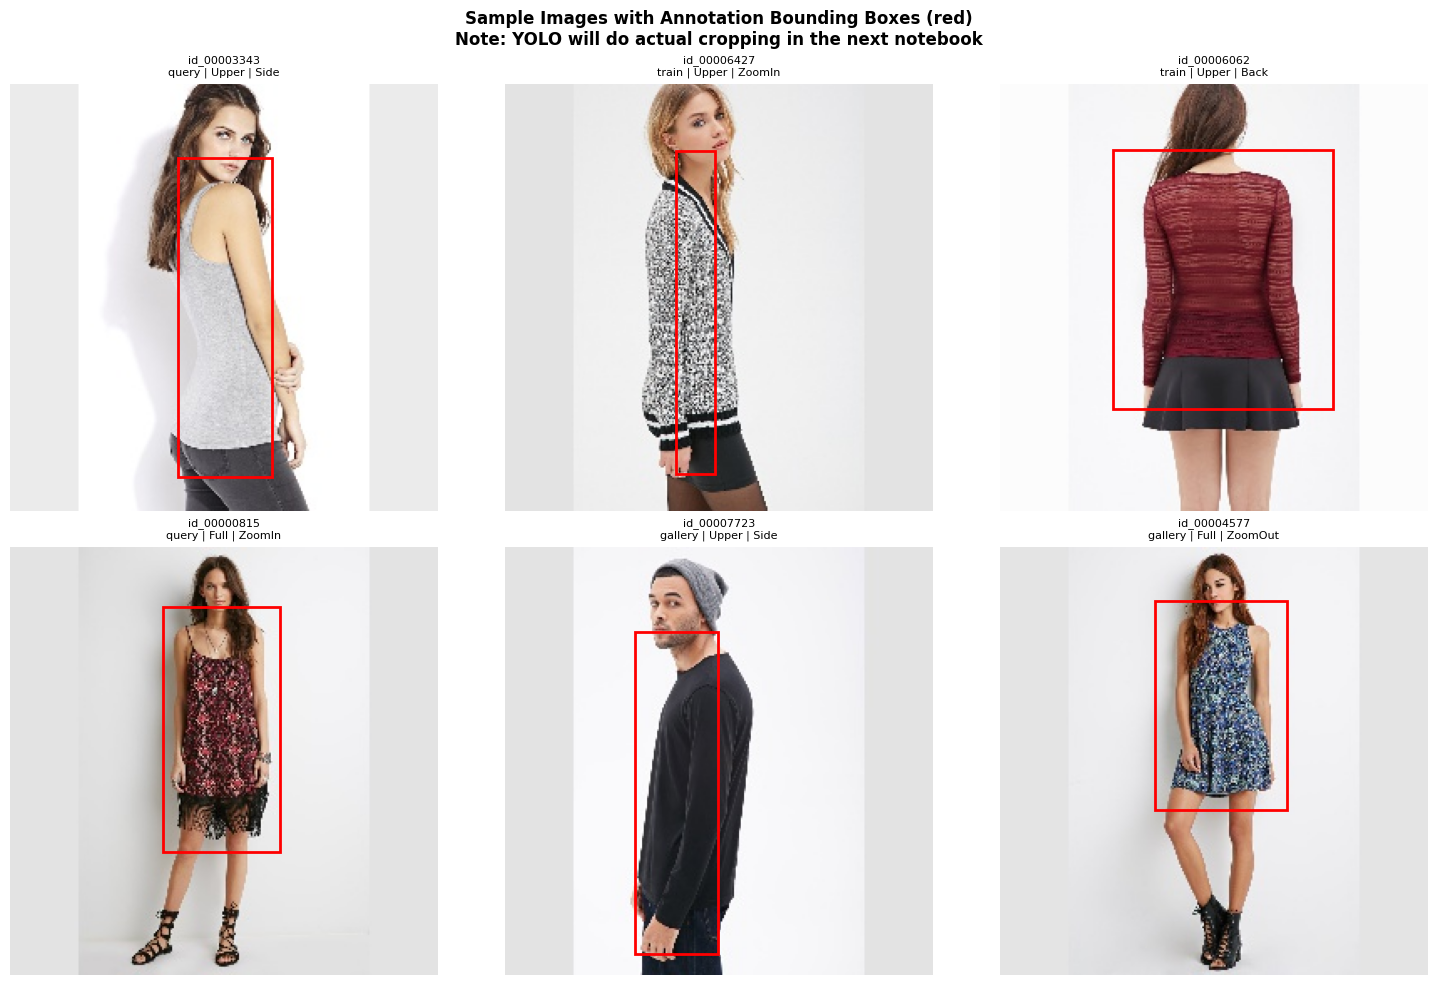

In [7]:
samples = df_master.sample(6, random_state=7)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    path = get_full_path(row['image_name'])
    if not os.path.exists(path):
        continue
    img = Image.open(path).convert('RGB')
    axes[i].imshow(img)

    # Draw annotation bounding box in red
    x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    axes[i].add_patch(rect)

    clothes = {1: 'Upper', 2: 'Lower', 3: 'Full'}.get(row['clothes_type'], '?')
    pose    = {1: 'Front', 2: 'Side', 3: 'Back',
               4: 'ZoomOut', 5: 'ZoomIn', 6: 'Standalone'}.get(row['pose_type'], '?')
    axes[i].set_title(
        f"{row['item_id']}\n{row['split']} | {clothes} | {pose}", fontsize=8
    )
    axes[i].axis('off')

plt.suptitle(
    'Sample Images with Annotation Bounding Boxes (red)\n'
    'Note: YOLO will do actual cropping in the next notebook',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Step 8: Verify Contrastive Training Pairs

For CLIP fine-tuning, we need at least 2 images per item_id in the train split.
One image acts as the anchor and one as the positive match.
Items with only 1 image cannot be used for contrastive training and will be skipped.

=== Train Split — Images per Item ID ===
Total train images          : 25882
Unique item IDs in train    : 3997
Avg images per item         : 6.48
Min images per item         : 1
Max images per item         : 162
Items with >= 2 images      : 3985  (usable for contrastive training)
Items with only 1 image     : 12  (will be skipped in CLIP fine-tuning)


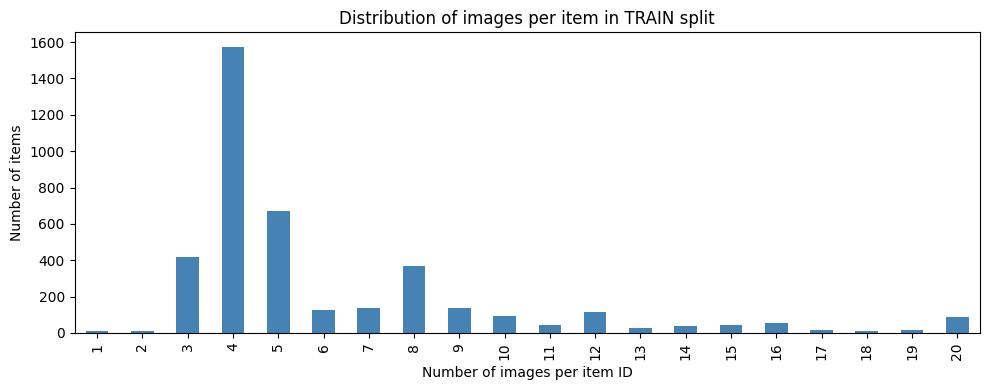

In [8]:
train_df    = df_master[df_master['split'] == 'train']
item_counts = train_df.groupby('item_id').size()

print('=== Train Split — Images per Item ID ===')
print(f'Total train images          : {len(train_df)}')
print(f'Unique item IDs in train    : {item_counts.shape[0]}')
print(f'Avg images per item         : {item_counts.mean():.2f}')
print(f'Min images per item         : {item_counts.min()}')
print(f'Max images per item         : {item_counts.max()}')
print(f'Items with >= 2 images      : {(item_counts >= 2).sum()}  (usable for contrastive training)')
print(f'Items with only 1 image     : {(item_counts == 1).sum()}  (will be skipped in CLIP fine-tuning)')

plt.figure(figsize=(10, 4))
item_counts.clip(upper=20).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('Number of images per item ID')
plt.ylabel('Number of items')
plt.title('Distribution of images per item in TRAIN split')
plt.tight_layout()
plt.show()

## Step 9: Save All CSVs

These 4 CSV files are the only output of this notebook.
They will be used by every future notebook — YOLO, BLIP-2, CLIP, FAISS, evaluation.

Each CSV contains: image_name, item_id, split, clothes_type, pose_type, x1, y1, x2, y2

The bbox columns (x1,y1,x2,y2) are kept as fallback for YOLO in the next notebook.

In [9]:
# Full master — all splits combined
df_master.to_csv(os.path.join(OUTPUT_DIR, 'master_df.csv'), index=False)

# Per-split CSVs
train_df   = df_master[df_master['split'] == 'train'].reset_index(drop=True)
query_df   = df_master[df_master['split'] == 'query'].reset_index(drop=True)
gallery_df = df_master[df_master['split'] == 'gallery'].reset_index(drop=True)

train_df.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False)
query_df.to_csv(os.path.join(OUTPUT_DIR, 'query.csv'), index=False)
gallery_df.to_csv(os.path.join(OUTPUT_DIR, 'gallery.csv'), index=False)

print('=== Saved Files ===')
print(f'master_df.csv  :  {len(df_master)} rows')
print(f'train.csv      :  {len(train_df)} rows')
print(f'query.csv      :  {len(query_df)} rows')
print(f'gallery.csv    :  {len(gallery_df)} rows')

print('\nColumns in each CSV:')
print(df_master.columns.tolist())

print('\nFiles in /kaggle/working:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(full):
        size = os.path.getsize(full)
        print(f'  {f}  ({size:,} bytes)')

=== Saved Files ===
master_df.csv  :  52712 rows
train.csv      :  25882 rows
query.csv      :  14218 rows
gallery.csv    :  12612 rows

Columns in each CSV:
['image_name', 'item_id', 'split', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2']

Files in /kaggle/working:
  __notebook__.ipynb  (928,003 bytes)
  gallery.csv  (1,077,075 bytes)
  master_df.csv  (4,458,315 bytes)
  query.csv  (1,202,804 bytes)
  train.csv  (2,178,556 bytes)


## Step 10: Final Summary

In [10]:
print('=' * 55)
print('         PREPROCESSING COMPLETE — SUMMARY')
print('=' * 55)
print(f'  Total images       : {len(df_master)}')
print(f'  Train images       : {len(train_df)}')
print(f'  Query images       : {len(query_df)}')
print(f'  Gallery images     : {len(gallery_df)}')
print(f'  Unique item IDs    : {df_master["item_id"].nunique()}')
print()
print('  Output CSV files (save these as a Kaggle dataset):')
print('    /kaggle/working/master_df.csv')
print('    /kaggle/working/train.csv')
print('    /kaggle/working/query.csv')
print('    /kaggle/working/gallery.csv')
print()
print('  NO cropped images produced here.')
print('  Cropping will be done by YOLO in the next notebook.')
print('=' * 55)

         PREPROCESSING COMPLETE — SUMMARY
  Total images       : 52712
  Train images       : 25882
  Query images       : 14218
  Gallery images     : 12612
  Unique item IDs    : 7982

  Output CSV files (save these as a Kaggle dataset):
    /kaggle/working/master_df.csv
    /kaggle/working/train.csv
    /kaggle/working/query.csv
    /kaggle/working/gallery.csv

  NO cropped images produced here.
  Cropping will be done by YOLO in the next notebook.
